# Lab: Support Vector Machines with scikit-learn

In the [theory notes](./14_support_vector_machines_theory.md), we learned that a Support Vector Machine finds the **maximum-margin hyperplane** — the decision boundary that creates the widest possible "street" between classes. In the [implementation file](./15_support_vector_machines_implementation.py), we built a linear SVM from scratch using hinge loss and gradient descent.

**Now it's time to use the real thing.** scikit-learn's `SVC` handles the optimization, kernel computations, and multi-class strategies for us. In this lab, we will learn how to:

1. Load and prepare a classification dataset (with **feature scaling** — mandatory for SVMs).
2. Build and train an `SVC` with different kernels.
3. **Visualize the decision boundaries** and margins produced by each kernel.
4. Understand the key hyperparameters (`C`, `kernel`, `gamma`).
5. Inspect the **support vectors** — the points that actually define the boundary.
6. See how `C` controls the margin width (hard vs. soft margin).
7. Demonstrate **why feature scaling is critical** for SVMs.

---

## 1. The Dataset

We'll use the **Iris dataset** — the same classic multi-class classification benchmark from the Decision Trees lab. The goal is to classify iris flowers into three species (*setosa*, *versicolor*, *virginica*) based on four petal/sepal measurements.

SVMs are a great fit because:
- The dataset is **low-dimensional** (4 features) — SVMs excel in low-to-medium dimensions.
- The classes have **clear geometric separation** in feature space.
- SVMs can handle the **overlap between versicolor and virginica** using soft margins or non-linear kernels.

Let's start by importing our libraries and loading the data.

In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

# Configurations
plt.style.use("fivethirtyeight")
sns.set_theme(style="white", palette="colorblind")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["figure.dpi"] = 150

In [2]:
# Load the Iris dataset
iris = load_iris()

feature_names = list(iris.feature_names)
target_names = list(iris.target_names)

df = pd.DataFrame(iris.data, columns=feature_names)
df["species"] = [target_names[t] for t in iris.target]
df["target"] = iris.target

print(f"Dataset: {df.shape[0]} samples, {len(feature_names)} features")
print(f"Classes: {target_names}")
print(f"Class distribution:\n{df['species'].value_counts().to_string()}")
print()
df.sample(5, random_state=42)

Dataset: 150 samples, 4 features
Classes: [np.str_('setosa'), np.str_('versicolor'), np.str_('virginica')]
Class distribution:
species
setosa        50
versicolor    50
virginica     50



,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species,target
73,6.1,2.8,4.7,1.2,versicolor,1
18,5.7,3.8,1.7,0.3,setosa,0
118,7.7,2.6,6.9,2.3,virginica,2
78,6.0,2.9,4.5,1.5,versicolor,1
76,6.8,2.8,4.8,1.4,versicolor,1


---

## 2. Feature Scaling — Mandatory for SVMs

This is the single most important preprocessing step for SVMs. As the theory notes emphasize:

> *"Because SVM tries to maximize physical distance (Euclidean distance), features with large scales will dominate the margin. You **must** normalize/standardize data before training an SVM."*

Unlike decision trees (which split on thresholds and are scale-invariant), SVMs compute **distances** in feature space. If one feature ranges from 0–1 and another from 0–1000, the margin will be completely distorted.

`StandardScaler` transforms each feature to zero mean and unit variance: $x_{\text{scaled}} = \frac{x - \mu}{\sigma}$

In [3]:
# Separate features and target
X = df[feature_names].values
y = df["target"].values

# Scale features — CRITICAL for SVMs
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Before scaling:")
print(f"  Feature means: {X.mean(axis=0).round(2)}")
print(f"  Feature stds:  {X.std(axis=0).round(2)}")
print()
print("After scaling:")
print(f"  Feature means: {X_scaled.mean(axis=0).round(2)}")
print(f"  Feature stds:  {X_scaled.std(axis=0).round(2)}")

Before scaling:
  Feature means: [5.84 3.06 3.76 1.2 ]
  Feature stds:  [0.83 0.43 1.76 0.76]

After scaling:
  Feature means: [-0. -0. -0. -0.]
  Feature stds:  [1. 1. 1. 1.]


---

## 3. Building an SVM Classifier

scikit-learn's `SVC` (Support Vector Classification) is the main SVM class. Key parameters:

| Parameter | What It Does | Default |
|---|---|---|
| `C` | Regularization — inverse of $\lambda$ from the theory. Higher C = narrower margin, stricter. | `1.0` |
| `kernel` | The kernel function (`"linear"`, `"rbf"`, `"poly"`) | `"rbf"` |
| `gamma` | Kernel coefficient for RBF/poly (`"scale"` or `"auto"` or a float) | `"scale"` |
| `degree` | Degree of the polynomial kernel | `3` |
| `random_state` | Seed for reproducibility | `None` |

Let's train our first SVM with the default RBF kernel:

In [4]:
# Build an SVM with the default RBF kernel
svm_rbf = SVC(kernel="rbf", random_state=42)
svm_rbf.fit(X_scaled, y)

print("SVM trained with RBF kernel!")
print(f"  Kernel: {svm_rbf.kernel}")
print(f"  C: {svm_rbf.C}")
print(f"  gamma: {svm_rbf.gamma}")
print(f"  Number of support vectors per class: {svm_rbf.n_support_}")
print(f"  Total support vectors: {svm_rbf.support_vectors_.shape[0]} out of {X_scaled.shape[0]} samples")

SVM trained with RBF kernel!
  Kernel: rbf
  C: 1.0
  gamma: scale
  Number of support vectors per class: [ 8 22 21]
  Total support vectors: 51 out of 150 samples


---

## 4. Understanding Support Vectors

The key insight from the theory is that **only the support vectors matter** — they are the data points closest to the decision boundary that "support" or define it. All other points could be removed without changing the boundary.

Let's inspect them:

In [5]:
# Get the support vector indices and their class labels
sv_indices = svm_rbf.support_
sv_labels = y[sv_indices]

print(f"Support vector breakdown:")
for i, name in enumerate(target_names):
    n_sv = svm_rbf.n_support_[i]
    n_total = (y == i).sum()
    print(f"  {name}: {n_sv} support vectors out of {n_total} samples ({n_sv/n_total*100:.0f}%)")

print(f"\n📌 Notice: setosa has very few support vectors because it's easily separable.")
print(f"   versicolor and virginica have more — they overlap in feature space, so the")
print(f"   SVM needs more boundary-defining points to separate them.")

Support vector breakdown:
  setosa: 8 support vectors out of 50 samples (16%)
  versicolor: 22 support vectors out of 50 samples (44%)
  virginica: 21 support vectors out of 50 samples (42%)

📌 Notice: setosa has very few support vectors because it's easily separable.
   versicolor and virginica have more — they overlap in feature space, so the
   SVM needs more boundary-defining points to separate them.


---

## 5. Visualizing Decision Boundaries

To visualize the SVM decision boundary, we'll project the data onto **two features at a time** (since we can only plot in 2D). We'll use the two most informative features — petal length and petal width — which provide the best separation.

### 5.1. Comparing Kernels

Let's train three SVMs with different kernels and see how each one draws the boundary:

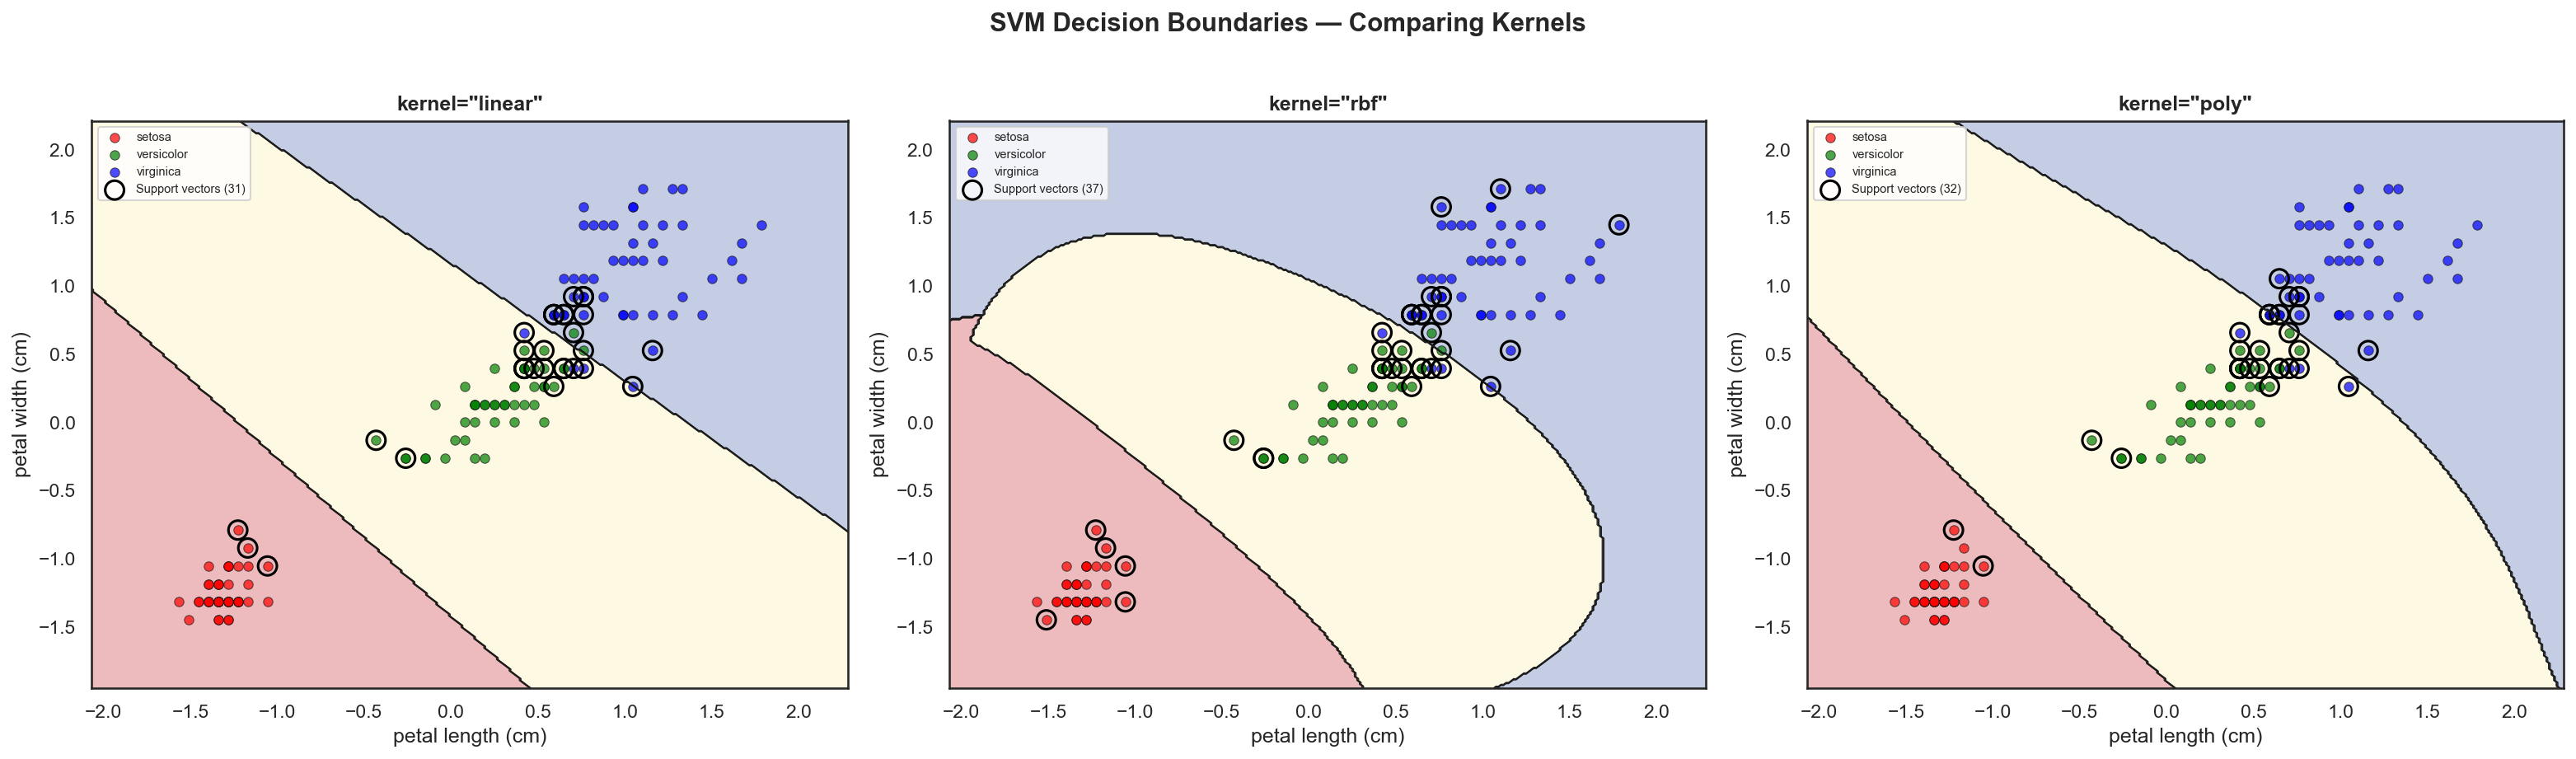

In [6]:
# Use only petal_length and petal_width for 2D visualization
X_2d = X_scaled[:, 2:4]  # petal_length (idx 2), petal_width (idx 3)
feature_pair = ["petal length (cm)", "petal width (cm)"]

kernels = ["linear", "rbf", "poly"]
fig, axes = plt.subplots(1, 3, figsize=(21, 6))

for ax, kernel in zip(axes, kernels):
    # Train on the 2D subset
    svm = SVC(kernel=kernel, C=1.0, gamma="scale", random_state=42)
    svm.fit(X_2d, y)

    # Create mesh grid for the background
    x_min, x_max = X_2d[:, 0].min() - 0.5, X_2d[:, 0].max() + 0.5
    y_min, y_max = X_2d[:, 1].min() - 0.5, X_2d[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300), np.linspace(y_min, y_max, 300))
    Z = svm.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

    # Plot decision regions
    ax.contourf(xx, yy, Z, alpha=0.3, cmap="RdYlBu")
    ax.contour(xx, yy, Z, colors="k", linewidths=0.5)

    # Plot all data points
    colors = ["red", "green", "blue"]
    for i, (name, color) in enumerate(zip(target_names, colors)):
        mask = y == i
        ax.scatter(X_2d[mask, 0], X_2d[mask, 1], c=color, label=name, s=30,
                   edgecolors="k", linewidths=0.5, alpha=0.7)

    # Highlight support vectors
    ax.scatter(svm.support_vectors_[:, 0], svm.support_vectors_[:, 1],
               s=120, facecolors="none", edgecolors="black", linewidths=1.5,
               label=f"Support vectors ({len(svm.support_vectors_)})")

    ax.set_xlabel(feature_pair[0])
    ax.set_ylabel(feature_pair[1])
    ax.set_title(f'kernel="{kernel}"', fontweight="bold")
    ax.legend(loc="upper left", fontsize=7)

fig.suptitle("SVM Decision Boundaries — Comparing Kernels", fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

### 📌 What to Notice

- **`linear`**: Straight-line boundaries (hyperplanes). Works well when classes are linearly separable. The setosa region has a clean line; the versicolor/virginica boundary is also linear.
- **`rbf`** (Radial Basis Function): Curved, flexible boundaries. This is the default kernel in scikit-learn and usually works well. It creates boundaries based on the *distance* from support vectors.
- **`poly`** (Polynomial): Curved boundaries, but constrained to polynomial shapes. The degree parameter controls complexity.

Notice how the **circled points** are the support vectors — they sit right at the boundary between classes. The RBF kernel needs more support vectors because it creates a more complex boundary.

This connects directly to the **Kernel Trick** from the theory: *"Instead of transforming data into high dimensions manually, we use a mathematical shortcut (kernel function) to calculate dot products as if the data were in higher dimensions."*

---

## 6. The Effect of `C`: Hard vs. Soft Margin

The theory explains that `C` is inversely related to the regularization parameter $\lambda$:
- **Large C** → narrow margin, fewer errors allowed ("hard margin")
- **Small C** → wide margin, more errors tolerated ("soft margin")

Let's visualize this trade-off:

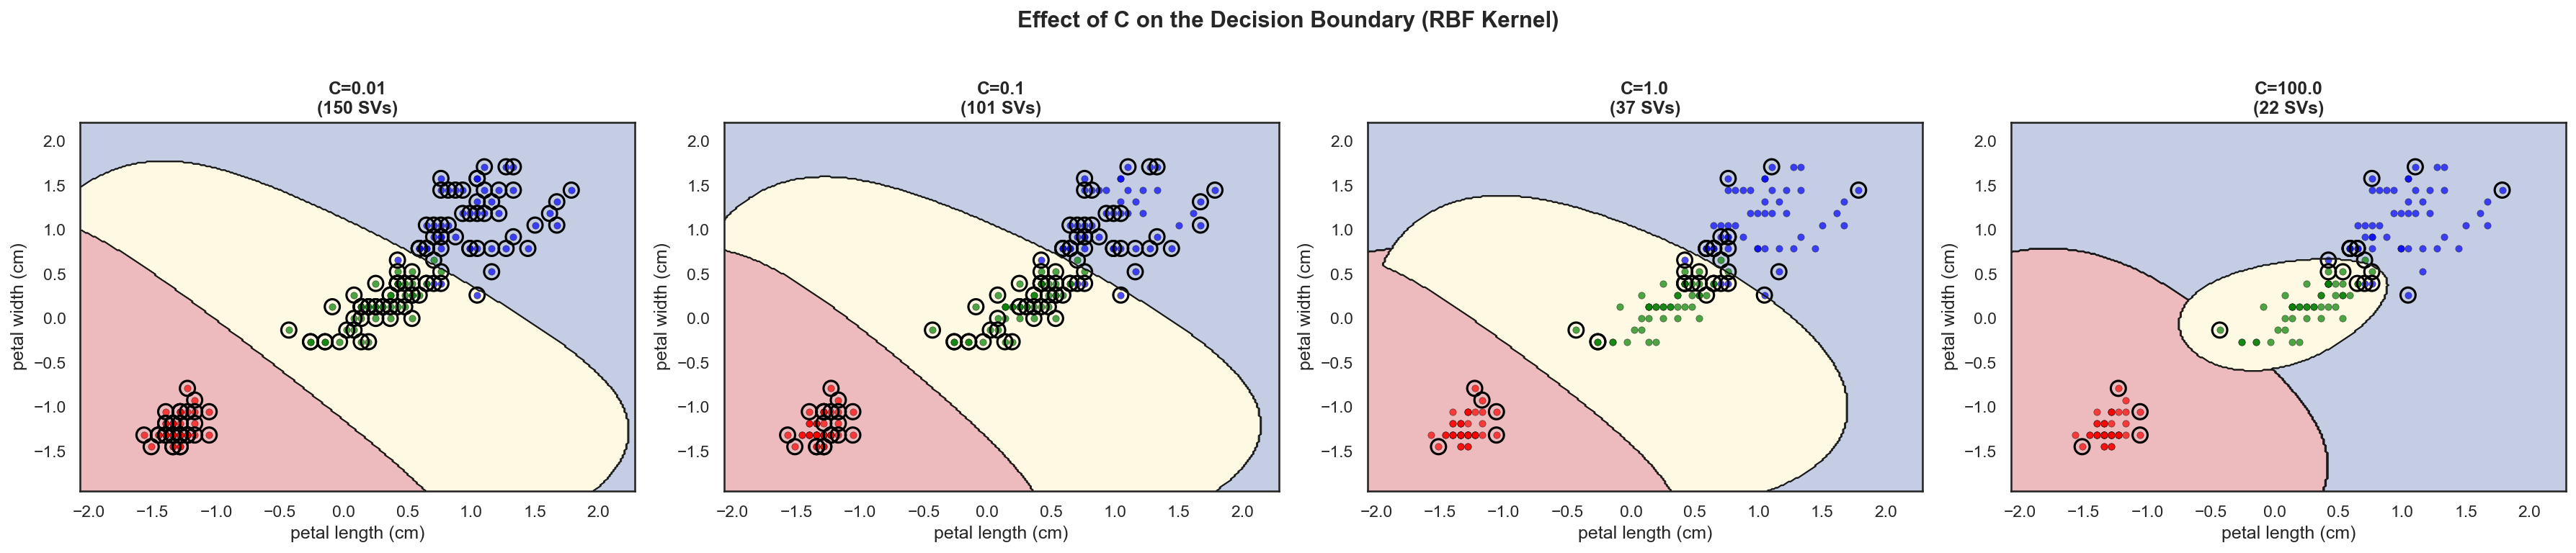

In [7]:
C_values = [0.01, 0.1, 1.0, 100.0]
fig, axes = plt.subplots(1, 4, figsize=(24, 5))

for ax, C in zip(axes, C_values):
    svm = SVC(kernel="rbf", C=C, gamma="scale", random_state=42)
    svm.fit(X_2d, y)

    # Mesh grid
    x_min, x_max = X_2d[:, 0].min() - 0.5, X_2d[:, 0].max() + 0.5
    y_min, y_max = X_2d[:, 1].min() - 0.5, X_2d[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300), np.linspace(y_min, y_max, 300))
    Z = svm.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

    ax.contourf(xx, yy, Z, alpha=0.3, cmap="RdYlBu")
    ax.contour(xx, yy, Z, colors="k", linewidths=0.5)

    for i, (name, color) in enumerate(zip(target_names, ["red", "green", "blue"])):
        mask = y == i
        ax.scatter(X_2d[mask, 0], X_2d[mask, 1], c=color, s=20, edgecolors="k", linewidths=0.3, alpha=0.7)

    ax.scatter(svm.support_vectors_[:, 0], svm.support_vectors_[:, 1],
               s=100, facecolors="none", edgecolors="black", linewidths=1.5)

    ax.set_title(f"C={C}\n({len(svm.support_vectors_)} SVs)", fontweight="bold")
    ax.set_xlabel(feature_pair[0])
    ax.set_ylabel(feature_pair[1])

fig.suptitle("Effect of C on the Decision Boundary (RBF Kernel)", fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

### 📌 Hard Margin vs. Soft Margin

- **C=0.01 (very soft)**: Wide margin — the boundary is smooth and simple. Many points are allowed inside the margin or even misclassified. More support vectors are needed. Underfits.
- **C=1.0 (default)**: A balanced trade-off between margin width and classification accuracy.
- **C=100 (very hard)**: Narrow margin — the SVM tries very hard to classify every training point correctly. The boundary becomes more jagged and complex. Fewer support vectors, but the model may overfit.

This is exactly the theory's description: *"Large C → Strict. We punish errors heavily. Narrow margin, risk of overfitting. Small C → Loose. We allow some errors for a wider margin. Better generalization."*

---

## 7. The Effect of `gamma` (RBF Kernel)

For the RBF kernel, `gamma` controls how far the influence of a single training example reaches:
- **Small gamma** → each point has a **wide** sphere of influence → smoother boundary
- **Large gamma** → each point has a **narrow** sphere of influence → more complex, wiggly boundary

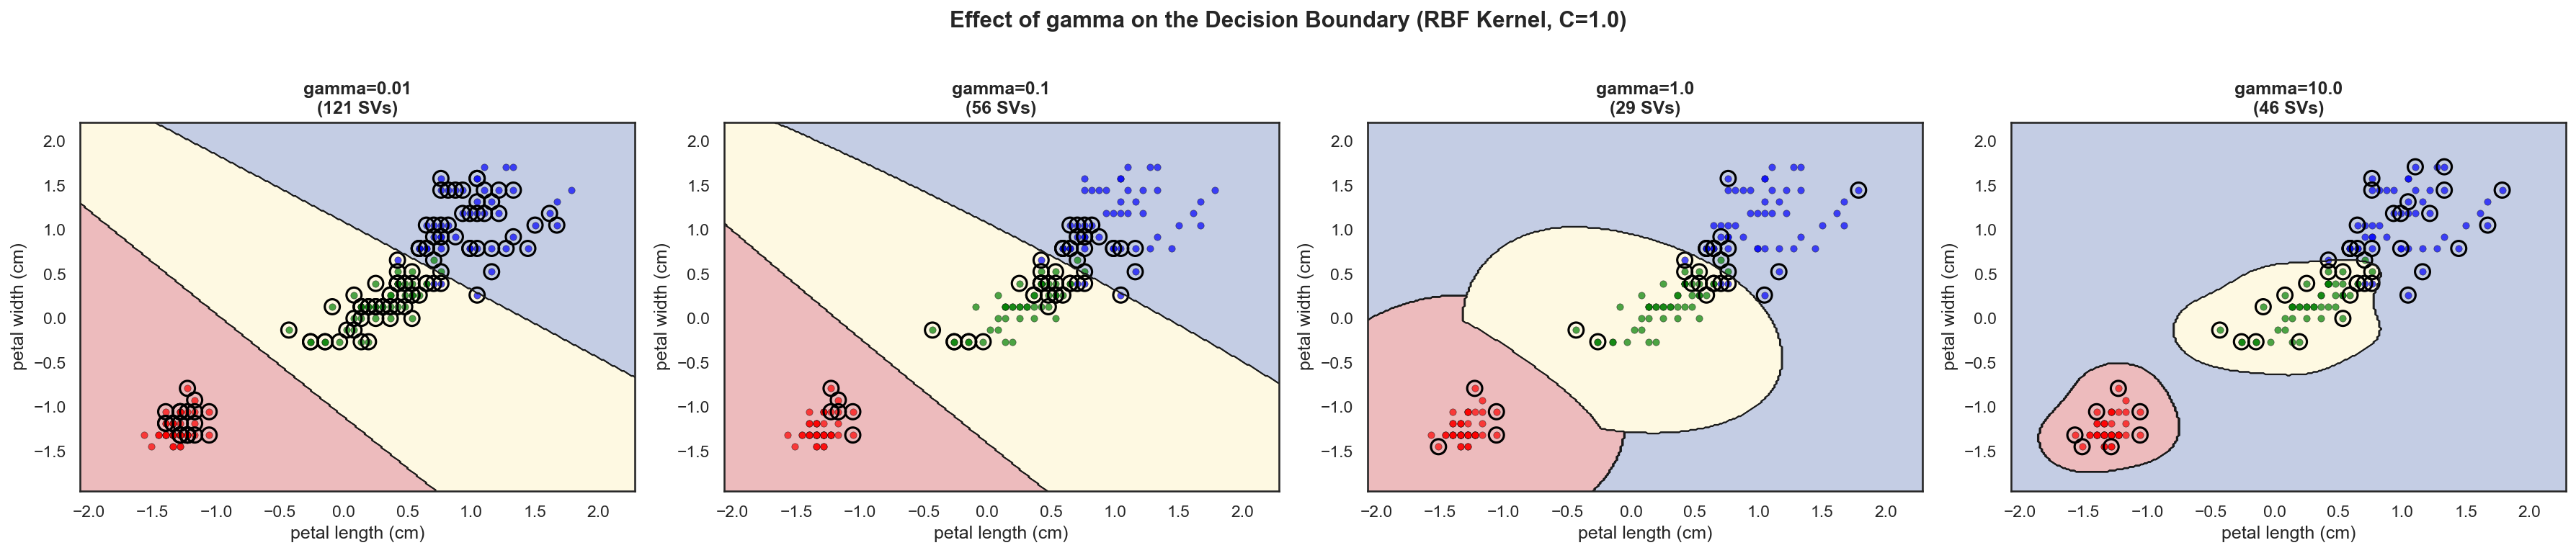

In [8]:
gamma_values = [0.01, 0.1, 1.0, 10.0]
fig, axes = plt.subplots(1, 4, figsize=(24, 5))

for ax, gamma in zip(axes, gamma_values):
    svm = SVC(kernel="rbf", C=1.0, gamma=gamma, random_state=42)
    svm.fit(X_2d, y)

    x_min, x_max = X_2d[:, 0].min() - 0.5, X_2d[:, 0].max() + 0.5
    y_min, y_max = X_2d[:, 1].min() - 0.5, X_2d[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300), np.linspace(y_min, y_max, 300))
    Z = svm.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

    ax.contourf(xx, yy, Z, alpha=0.3, cmap="RdYlBu")
    ax.contour(xx, yy, Z, colors="k", linewidths=0.5)

    for i, (name, color) in enumerate(zip(target_names, ["red", "green", "blue"])):
        mask = y == i
        ax.scatter(X_2d[mask, 0], X_2d[mask, 1], c=color, s=20, edgecolors="k", linewidths=0.3, alpha=0.7)

    ax.scatter(svm.support_vectors_[:, 0], svm.support_vectors_[:, 1],
               s=100, facecolors="none", edgecolors="black", linewidths=1.5)

    ax.set_title(f"gamma={gamma}\n({len(svm.support_vectors_)} SVs)", fontweight="bold")
    ax.set_xlabel(feature_pair[0])
    ax.set_ylabel(feature_pair[1])

fig.suptitle("Effect of gamma on the Decision Boundary (RBF Kernel, C=1.0)", fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

### 📌 Gamma Controls the "Reach" of Each Support Vector

- **gamma=0.01**: Very smooth, almost linear boundary. Each training point influences a large region. Underfits.
- **gamma=1.0**: Balanced — smooth curves that capture class structure.
- **gamma=10.0**: Very tight, complex boundaries. Each support vector only influences its immediate neighborhood. The model creates "islands" around individual points — severe overfitting.

Think of gamma as the inverse of the radius of the RBF kernel's bell curve: large gamma = narrow bell = each point only matters locally.

---

## 8. Why Scaling Matters: A Demonstration

The theory lists "Forgetting to Scale" as the **#1 mistake** with SVMs. Let's prove it by training on unscaled data and comparing:

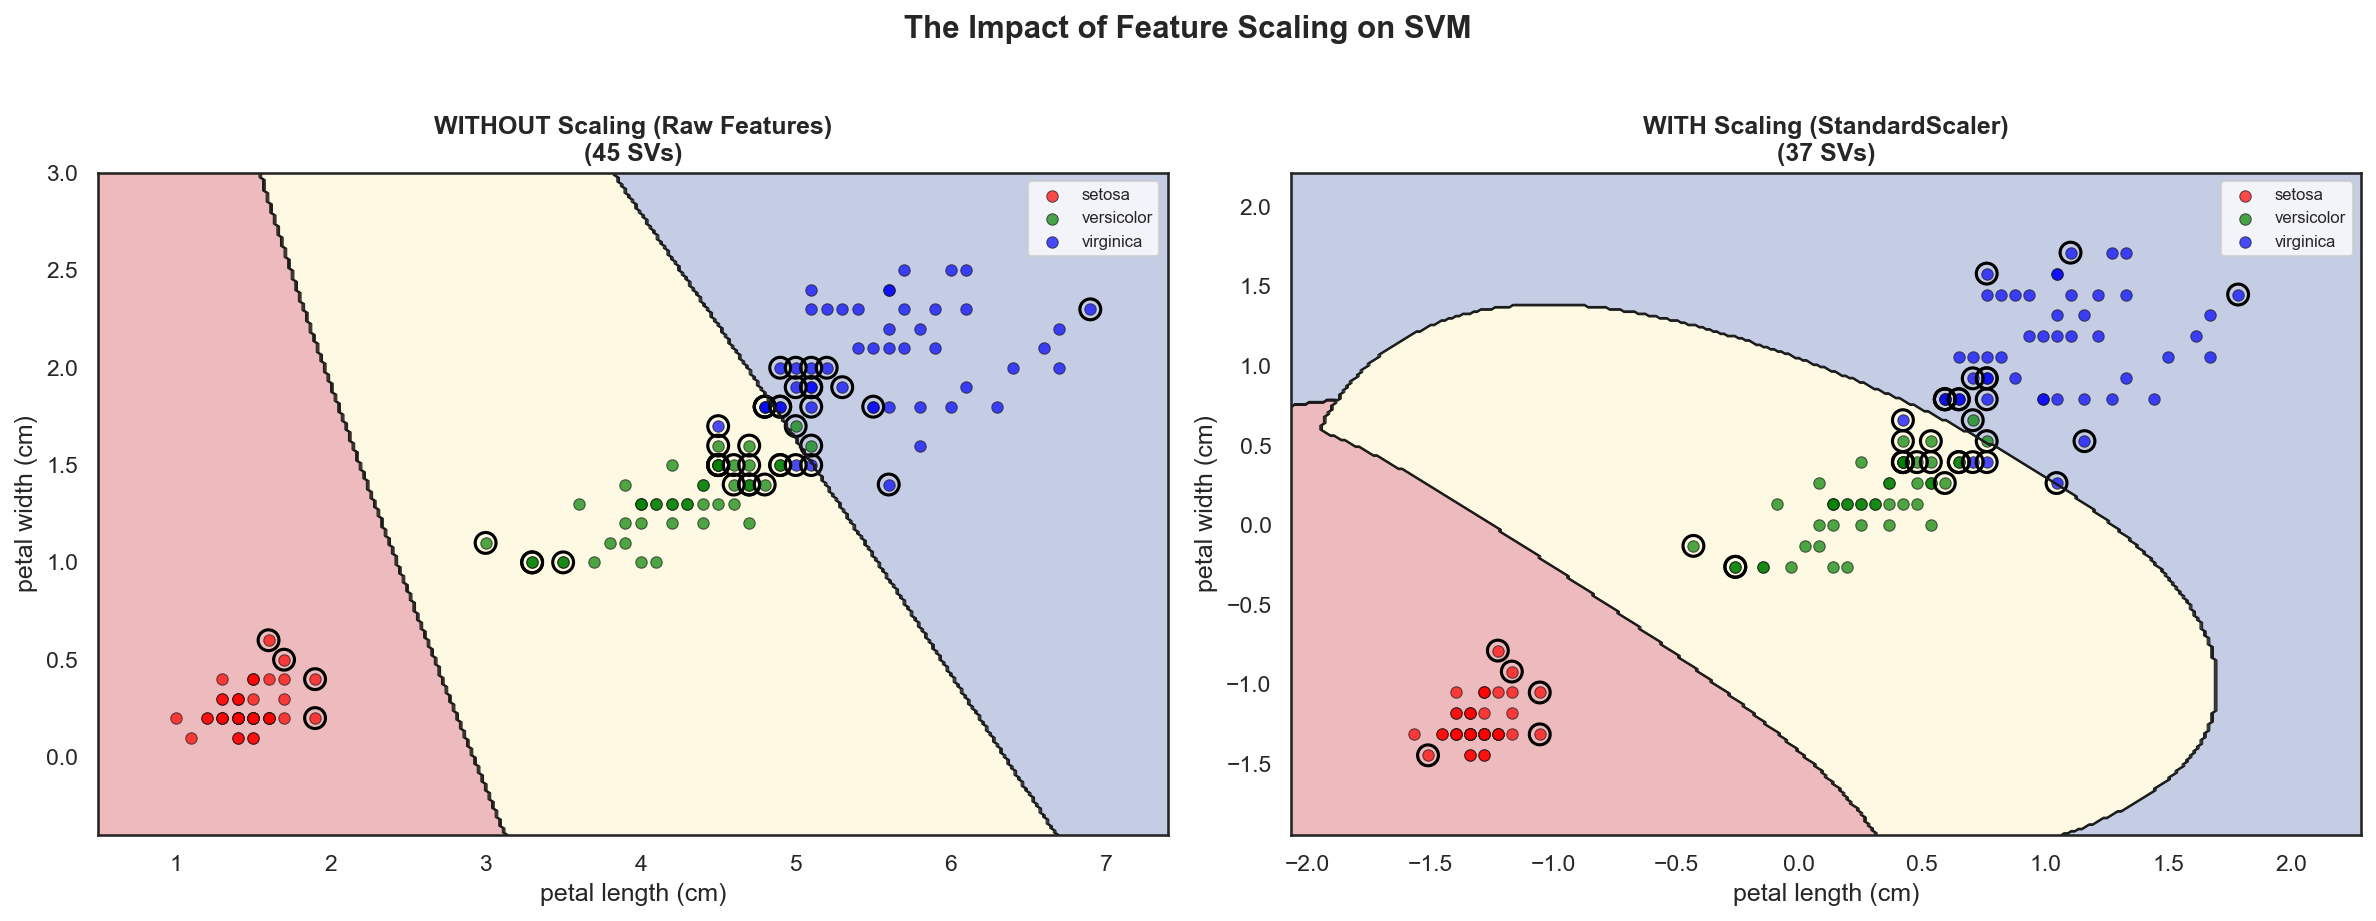

📌 With gamma='scale', scikit-learn auto-adjusts gamma based on feature variance,
   which partially compensates. But for features with very different scales
   (e.g., mixing cm and mm), scaling is absolutely critical.
   Always scale your data before training an SVM — it's non-negotiable.


In [9]:
# Compare scaled vs. unscaled on the same 2D features (petal_length, petal_width)
X_2d_unscaled = X[:, 2:4]  # petal features, NOT scaled

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
titles = ["WITHOUT Scaling (Raw Features)", "WITH Scaling (StandardScaler)"]
datasets = [X_2d_unscaled, X_2d]

for ax, data, title in zip(axes, datasets, titles):
    svm = SVC(kernel="rbf", C=1.0, gamma="scale", random_state=42)
    svm.fit(data, y)

    x_min, x_max = data[:, 0].min() - 0.5, data[:, 0].max() + 0.5
    y_min, y_max = data[:, 1].min() - 0.5, data[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300), np.linspace(y_min, y_max, 300))
    Z = svm.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

    ax.contourf(xx, yy, Z, alpha=0.3, cmap="RdYlBu")
    ax.contour(xx, yy, Z, colors="k", linewidths=0.5)

    for i, (name, color) in enumerate(zip(target_names, ["red", "green", "blue"])):
        mask = y == i
        ax.scatter(data[mask, 0], data[mask, 1], c=color, label=name, s=30,
                   edgecolors="k", linewidths=0.5, alpha=0.7)

    ax.scatter(svm.support_vectors_[:, 0], svm.support_vectors_[:, 1],
               s=100, facecolors="none", edgecolors="black", linewidths=1.5)

    ax.set_title(f"{title}\n({len(svm.support_vectors_)} SVs)", fontweight="bold")
    ax.set_xlabel(feature_pair[0])
    ax.set_ylabel(feature_pair[1])
    ax.legend(fontsize=8)

fig.suptitle("The Impact of Feature Scaling on SVM", fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

print("📌 With gamma='scale', scikit-learn auto-adjusts gamma based on feature variance,")
print("   which partially compensates. But for features with very different scales")
print("   (e.g., mixing cm and mm), scaling is absolutely critical.")
print("   Always scale your data before training an SVM — it's non-negotiable.")

---

## 9. Multi-Class Strategy: How scikit-learn Handles 3+ Classes

SVMs are inherently **binary classifiers** — they find a boundary between two classes. For multi-class problems like Iris (3 species), scikit-learn uses **one-vs-one (OvO)** by default: it trains one SVM for each pair of classes, then uses voting.

For 3 classes, that means 3 binary classifiers:
- setosa vs. versicolor
- setosa vs. virginica
- versicolor vs. virginica

In [10]:
# Show multi-class details
svm_full = SVC(kernel="rbf", C=1.0, random_state=42)
svm_full.fit(X_scaled, y)

print(f"Multi-class strategy: {svm_full.decision_function_shape}")
print(f"Number of classes: {len(svm_full.classes_)}")
print(f"Classes: {svm_full.classes_}")
print(f"\nSupport vectors per class: {svm_full.n_support_}")
print(f"Total support vectors: {svm_full.support_vectors_.shape[0]}")
print()

# Show the decision function for a sample
sample = X_scaled[75:76]  # a versicolor sample
decision_scores = svm_full.decision_function(sample)
prediction = svm_full.predict(sample)

print(f"Sample features (scaled): {sample[0].round(2)}")
print(f"Decision function scores: {decision_scores[0].round(3)}")
print(f"  → Score for each class (OvR-wrapped): higher = more confident")
print(f"Predicted class: {prediction[0]} ({target_names[prediction[0]]})")
print(f"True class: {y[75]} ({target_names[y[75]]})")

Multi-class strategy: ovr
Number of classes: 3
Classes: [0 1 2]

Support vectors per class: [ 8 22 21]
Total support vectors: 51

Sample features (scaled): [ 0.92 -0.13  0.36  0.26]
Decision function scores: [-0.22   2.238  0.881]
  → Score for each class (OvR-wrapped): higher = more confident
Predicted class: 1 (versicolor)
True class: 1 (versicolor)


---

## 10. Linear SVM: Inspecting the Weight Vector

For a **linear kernel**, the SVM learns an explicit weight vector $w$ and bias $b$ — just like in our from-scratch implementation. This makes the model directly interpretable: we can see which features contribute most to each class boundary.

In [11]:
# Train a linear SVM to inspect weights
svm_linear = SVC(kernel="linear", C=1.0, random_state=42)
svm_linear.fit(X_scaled, y)

# For OvO, there are n*(n-1)/2 = 3 binary classifiers
print("Weight vectors (one per binary classifier):")
print(f"  Shape: {svm_linear.coef_.shape}  (3 classifiers × 4 features)\n")

pairs = [(0, 1), (0, 2), (1, 2)]
for i, (c1, c2) in enumerate(pairs):
    weights = svm_linear.coef_[i]
    bias = svm_linear.intercept_[i]
    print(f"  {target_names[c1]} vs. {target_names[c2]}:")
    for fname, w in zip(feature_names, weights):
        print(f"    {fname:>25s}: {w:+.4f}")
    print(f"    {'bias':>25s}: {bias:+.4f}")
    print()

Weight vectors (one per binary classifier):
  Shape: (3, 4)  (3 classifiers × 4 features)

  setosa vs. versicolor:
            sepal length (cm): -0.4388
             sepal width (cm): +0.3318
            petal length (cm): -0.8919
             petal width (cm): -0.9230
                         bias: -1.4741

  setosa vs. virginica:
            sepal length (cm): -0.0646
             sepal width (cm): +0.1389
            petal length (cm): -0.5533
             petal width (cm): -0.5566
                         bias: -0.2952

  versicolor vs. virginica:
            sepal length (cm): +0.3102
             sepal width (cm): +0.6014
            petal length (cm): -2.4575
             petal width (cm): -2.4447
                         bias: +3.0977



### 📌 Interpreting the Weights

- For the **setosa vs. versicolor** boundary, `petal length` and `petal width` have the largest (most negative) weights — these petal features are the strongest separators.
- For the **versicolor vs. virginica** boundary, the weights are smaller and more distributed — these two classes overlap more, so the SVM needs information from multiple features.
- This is only possible with a **linear kernel**. For RBF and polynomial kernels, the boundary exists in a higher-dimensional space and there's no simple weight vector to inspect.

---

## Summary

In this lab, we learned how to use scikit-learn's `SVC` for classification. Here's what we covered:

| Step | What We Did | Key scikit-learn API |
|------|-------------|---------------------|
| Load data | Iris dataset (150 flowers, 3 species) | `load_iris()` |
| **Scale features** | `StandardScaler` — mandatory for SVMs | `StandardScaler().fit_transform()` |
| Build SVM | Trained `SVC` with various kernels | `SVC(kernel=...).fit(X, y)` |
| Visualize boundaries | 2D decision regions for linear, RBF, poly kernels | `.predict()` on a mesh grid |
| Support vectors | Inspected which points define the boundary | `.support_vectors_`, `.n_support_` |
| Effect of C | Showed hard margin (large C) vs. soft margin (small C) | `C` parameter |
| Effect of gamma | Showed smooth (small γ) vs. complex (large γ) boundaries | `gamma` parameter |
| Scaling impact | Demonstrated that unscaled data distorts the margin | Compared scaled vs. raw |
| Multi-class | OvO strategy with decision function scores | `.decision_function()` |
| Linear weights | Inspected the weight vector of a linear SVM | `.coef_`, `.intercept_` |

The key takeaways are:

1. **Feature scaling is mandatory** — SVMs compute distances, so scale matters.
2. **The kernel controls boundary shape** — `linear` for straight lines, `rbf` for flexible curves.
3. **`C` controls the margin trade-off** — larger C = harder margin, risk of overfitting.
4. **`gamma` controls the RBF "reach"** — larger gamma = more complex boundary.
5. **Only support vectors define the boundary** — most training points don't affect the model.
6. **Linear SVMs are interpretable** — you can inspect the weight vector.

---

**Next:** [KNN Theory](./17_knn_theory.md)